# Super Store — OOP Analysis Notebook


## 1. Build the dataset (loading + merging)

In [1]:
from Statistics import SalesDataBuilder, SalesDataCleaner, EDAVisualizer, HypothesisTester, InteractiveEDA

In [2]:
builder = SalesDataBuilder(base_path="/Users/faridradin/super-store/Data")
raw_df = builder.build()

--- date ---
(47483, 47)
0 null values

--- product ---
(10246, 4)
0 null values

--- customer ---
(1589, 3)
0 null values

--- geography ---
(3772, 6)
0 null values

--- shipMode ---
(4, 2)
0 null values

--- orderPriority ---
(4, 2)
0 null values

--- factSales ---
(49670, 15)
0 null values

FactSales dtypes:
 Product ID     object
CustomerID     object
GeoKey          int64
ShipModeID      int64
PriorityKey     int64
dtype: object

Product ProductID dtype: object
Customer CustomerID dtype: object
Geography GeoKey dtype: int64
ShipMode ShipModeID dtype: int64
OrderPriority PriorityKey dtype: int64
Initial number of rows: 49670
After Product: 49670
After Customer: 49670
After Geography: 49670
After ShipMode: 49670
After OrderPriority: 49670
After Order Date: 49670
After Ship Date: 49670
(49670, 42)
Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtyp

## 2. Clean the dataset

In [3]:
cleaner = SalesDataCleaner(raw_df)
df = cleaner.clean()

Duplicate rows: 0
SalesKey: 0
Rows with invalid dates: 0
Invalid Quantity: 0
Invalid Sales: 0
Invalid Discount: 0
Series([], dtype: int64)
--- Segment ---
Segment
Consumer       25724
Corporate      14927
Home Office     9019
Name: count, dtype: int64

--- Category ---
Category
Office Supplies    30287
Technology          9788
Furniture           9595
Name: count, dtype: int64

--- Sub-Category ---
Sub-Category
Binders        5967
Storage        4849
Art            4680
Paper          3479
Chairs         3340
Phones         3244
Furnishings    3088
Accessories    3011
Labels         2550
Envelopes      2374
Fasteners      2364
Supplies       2349
Bookcases      2319
Copiers        2133
Appliances     1675
Machines       1400
Tables          848
Name: count, dtype: int64

--- Region ---
Region
Central           10249
South              6490
EMEA               4835
North              4568
Africa             4453
Oceania            3487
West               3187
Southeast Asia     3129
East

In [4]:
cleaner.save_to_csv("/Users/faridradin/super-store/Data/sales_dataset_statistics.csv")

shape : (49670, 39)


# EDA

In [5]:
eda = EDAVisualizer(df)

In [6]:
eda.show_head()

,Order ID,Product ID,Sales,Quantity,Discount,Profit,Shipping Cost,CustomerID,OrderDate,IsReturned,...,Order_GregorianMonthName,Order_GregorianDayOfWeekName,Order_SeasonName,Order_IsGregorianLeap,Ship_GregorianYearInt,Ship_GregorianMonthNo,Ship_GregorianMonthName,Ship_GregorianDayOfWeekName,Ship_SeasonName,Ship_IsGregorianLeap
0,CA-2014-146780,FUR-FU-10001934,41.959999,2,0.0,10.9096,4.18,CV-12805,2014-12-26,No,...,December,Friday,Winter,0,2014,12,December,Wednesday,Winter,0
1,CA-2013-138520,OFF-EN-10001137,8.260000,2,0.0,3.7996,0.69,JL-15505,2013-04-09,No,...,April,Tuesday,Spring,0,2013,4,April,Sunday,Spring,0
2,CA-2014-144904,OFF-LA-10001158,20.700001,2,0.0,9.9360,0.74,KW-16435,2014-09-26,No,...,September,Friday,Fall,0,2014,10,October,Thursday,Fall,0
3,CA-2014-144904,OFF-AR-10003732,5.560000,2,0.0,1.4456,0.42,KW-16435,2014-09-26,No,...,September,Friday,Fall,0,2014,10,October,Thursday,Fall,0
4,CA-2013-123274,FUR-FU-10004090,44.459999,2,0.0,14.6718,3.97,GT-14710,2013-02-19,No,...,February,Tuesday,Winter,0,2013,2,February,Sunday,Winter,0


In [7]:
eda.describe_numeric()      # numerical

,count,mean,min,25%,50%,75%,max,std
Sales,49670.0,243.840355,0.444,30.384001,83.970001,247.829998,22638.5,485.963091
Quantity,49670.0,3.470787,1.0,2.0,3.0,5.0,14.0,2.274854
Discount,49670.0,0.14307,0.0,0.0,0.0,0.2,0.85,0.212046
Profit,49670.0,28.392264,-6599.97998,0.0,9.154,36.2664,8399.980469,172.39952
Shipping Cost,49670.0,26.041125,0.002,2.58,7.66,23.968999,933.570007,56.870281
OrderDate,49670,2013-05-08 10:27:27.578014720,2011-01-01 00:00:00,2012-06-15 00:00:00,2013-07-02 00:00:00,2014-05-19 00:00:00,2014-12-31 00:00:00,NaN
SalesKey,49670.0,24835.5,1.0,12418.25,24835.5,37252.75,49670.0,14338.638272
ShipDate,49670,2013-05-12 09:47:18.397423104,2011-01-03 00:00:00,2012-06-19 00:00:00,2013-07-05 00:00:00,2014-05-23 00:00:00,2015-01-07 00:00:00,NaN
PriorityKey,49670.0,1.594947,1.0,1.0,1.0,2.0,4.0,0.82074
GeoKey,49670.0,937.66811,1.0,178.0,656.0,1468.0,3772.0,908.479336


In [8]:
eda.describe_categorical()  # categorical

,count,unique,top,freq
Order ID,49670,25033,CA-2014-100111,14
Product ID,49670,10246,OFF-AR-10003651,32
CustomerID,49670,1589,PO-18850,97
IsReturned,49670,2,No,46690
ProductName,49670,3662,Staples,221
Category,49670,3,Office Supplies,30287
Sub-Category,49670,17,Binders,5967
CustomerName,49670,795,Steven Ward,104
Segment,49670,3,Consumer,25724
City,49670,3590,New York City,911


### Univariate Analysis_Numerical Variable

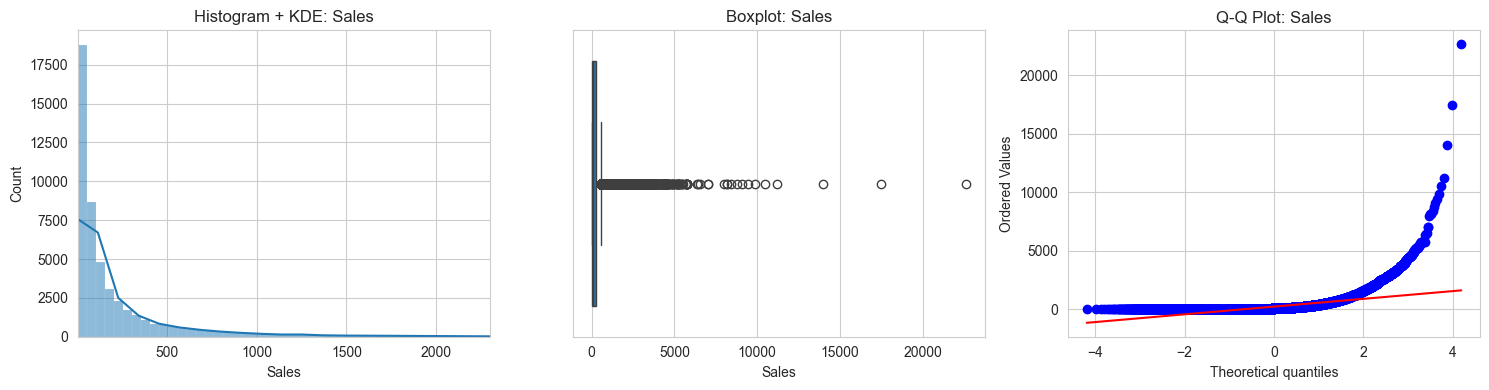

Sales: skewness=8.28, kurtosis=183.02


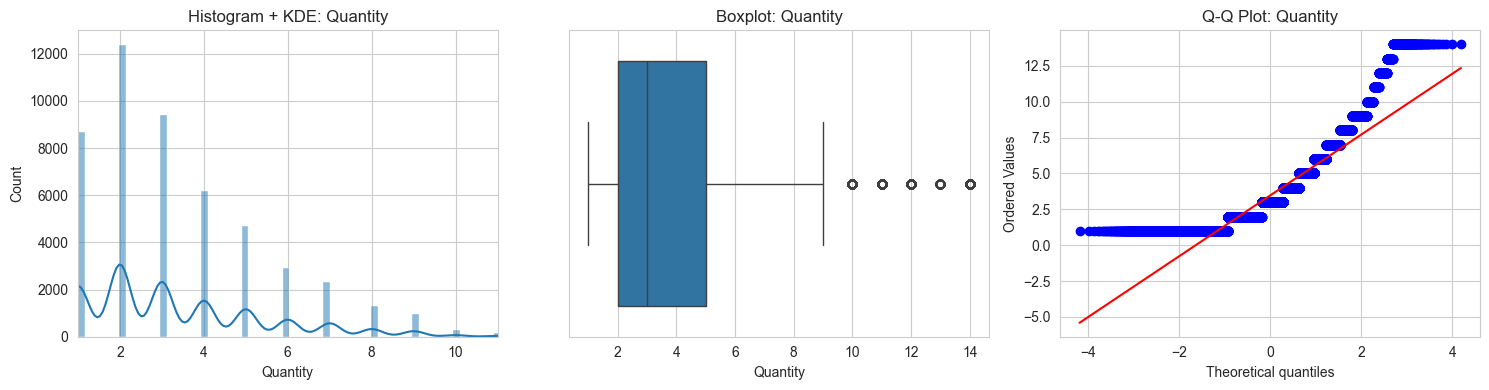

Quantity: skewness=1.36, kurtosis=2.28


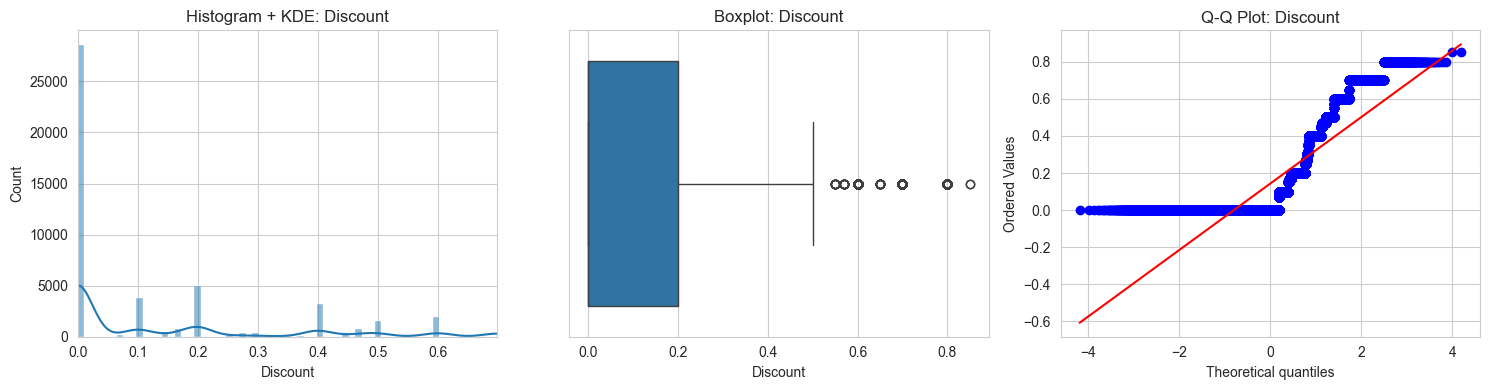

Discount: skewness=1.38, kurtosis=0.71


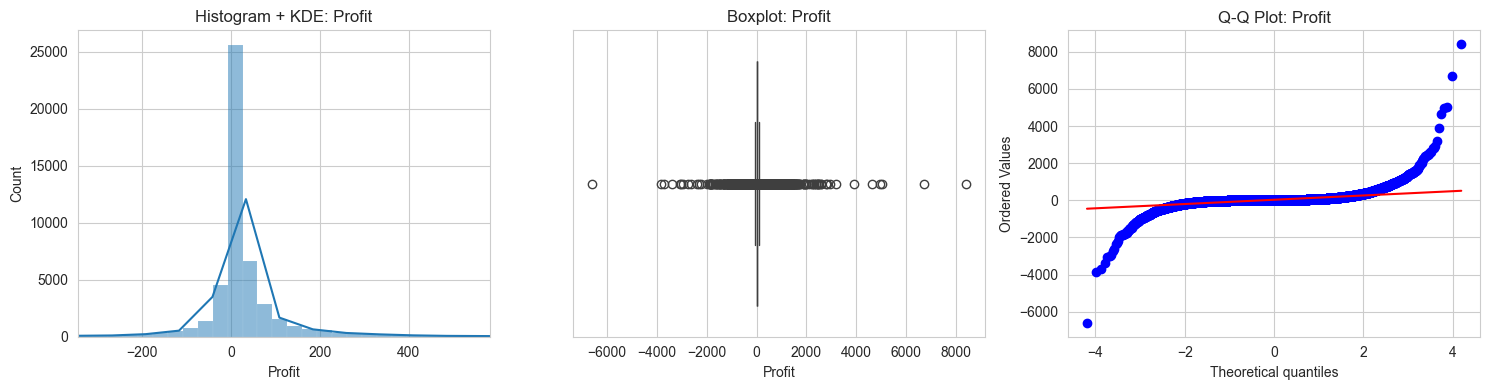

Profit: skewness=4.47, kurtosis=301.56


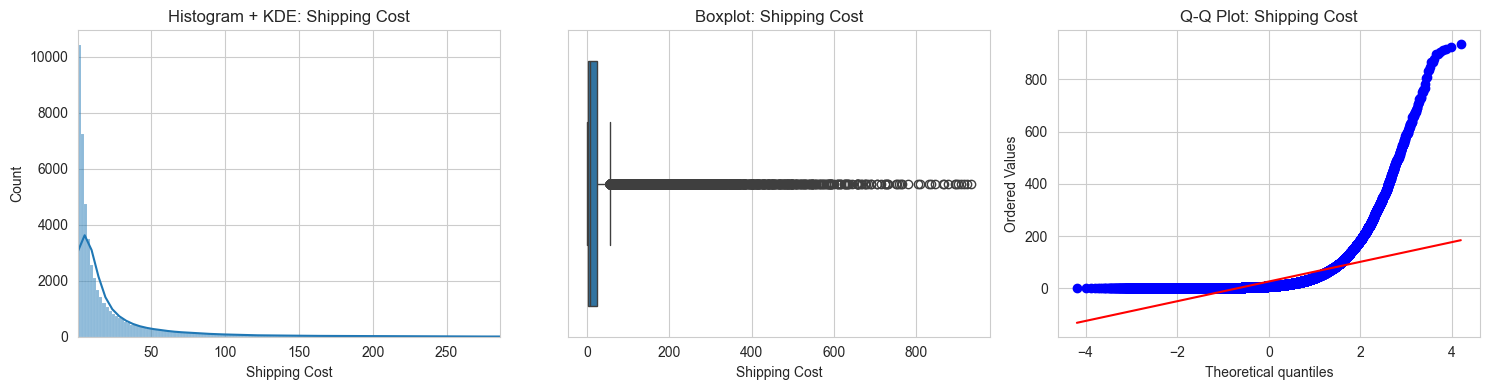

Shipping Cost: skewness=5.89, kurtosis=50.52


In [9]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
eda.plot_numeric_distributions(numeric_cols)

## Univariate Analysis_Categorical Variables

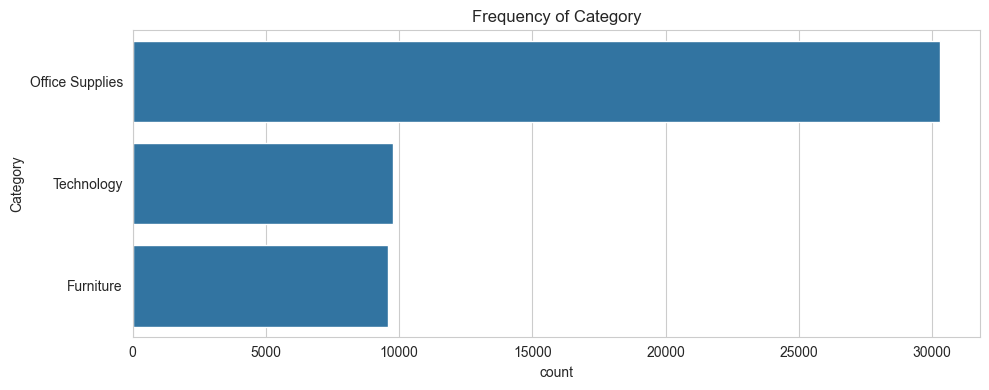

Category
Office Supplies    60.976445
Technology         19.706060
Furniture          19.317495
Name: proportion, dtype: float64


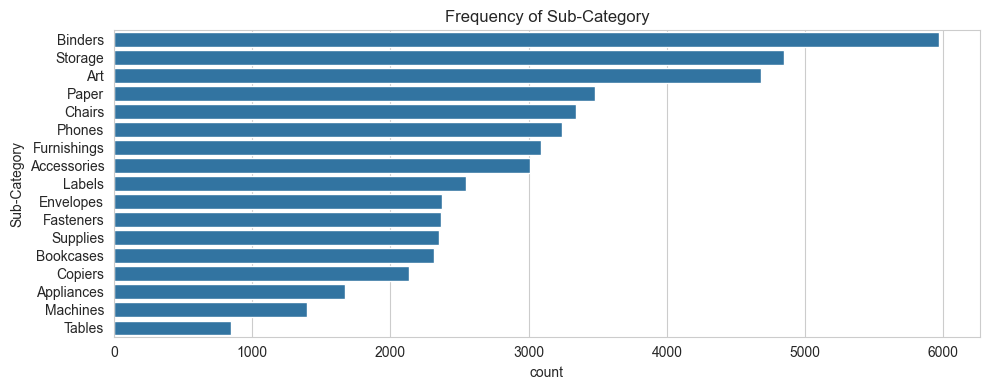

Sub-Category
Binders        12.013288
Storage         9.762432
Art             9.422186
Paper           7.004228
Chairs          6.724381
Phones          6.531105
Furnishings     6.217032
Accessories     6.062009
Labels          5.133884
Envelopes       4.779545
Fasteners       4.759412
Supplies        4.729213
Bookcases       4.668814
Copiers         4.294343
Appliances      3.372257
Machines        2.818603
Tables          1.707268
Name: proportion, dtype: float64


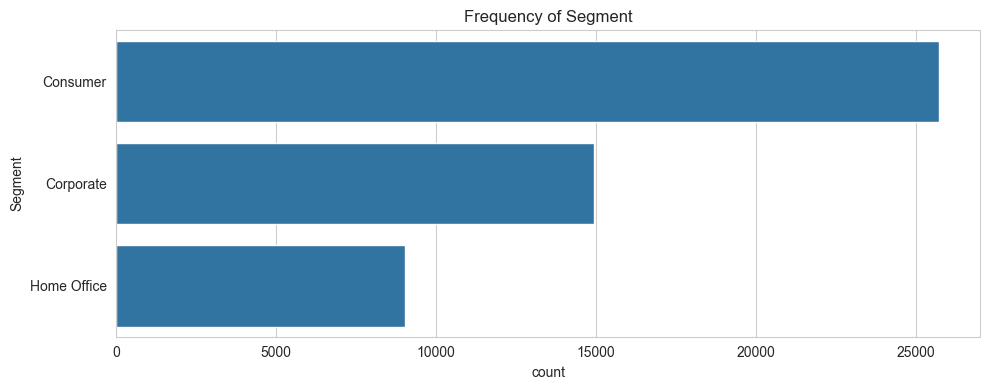

Segment
Consumer       51.789813
Corporate      30.052345
Home Office    18.157842
Name: proportion, dtype: float64


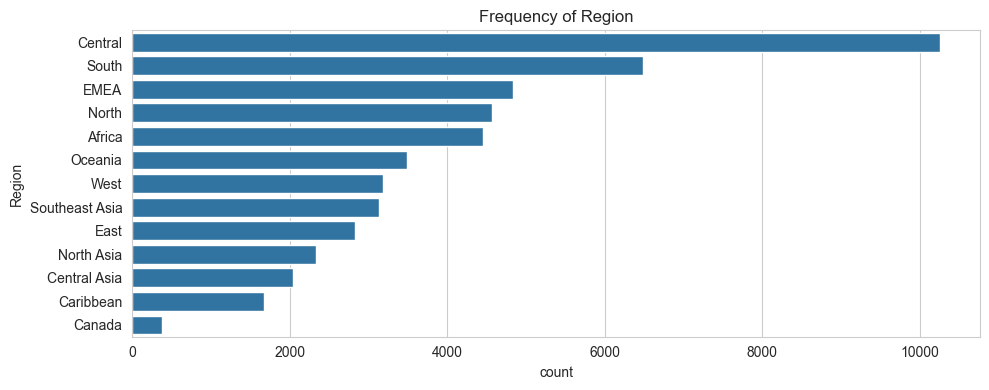

Region
Central           20.634186
South             13.066237
EMEA               9.734246
North              9.196698
Africa             8.965170
Oceania            7.020334
West               6.416348
Southeast Asia     6.299577
East               5.701631
North Asia         4.707067
Central Asia       4.123213
Caribbean          3.378297
Canada             0.756996
Name: proportion, dtype: float64


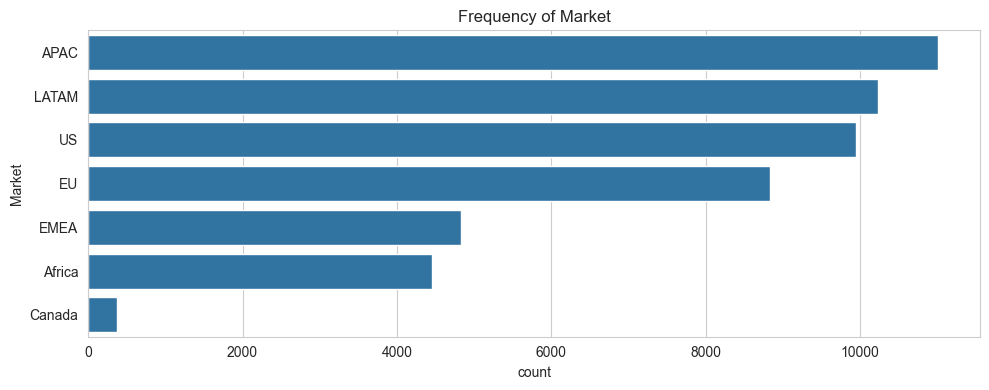

Market
APAC      22.150191
LATAM     20.593920
US        20.028186
EU        17.771291
EMEA       9.734246
Africa     8.965170
Canada     0.756996
Name: proportion, dtype: float64


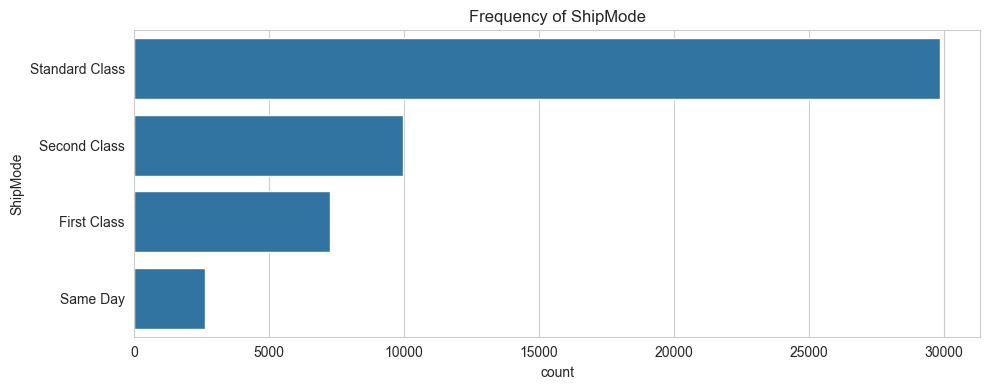

ShipMode
Standard Class    60.088585
Second Class      20.076505
First Class       14.560097
Same Day           5.274814
Name: proportion, dtype: float64


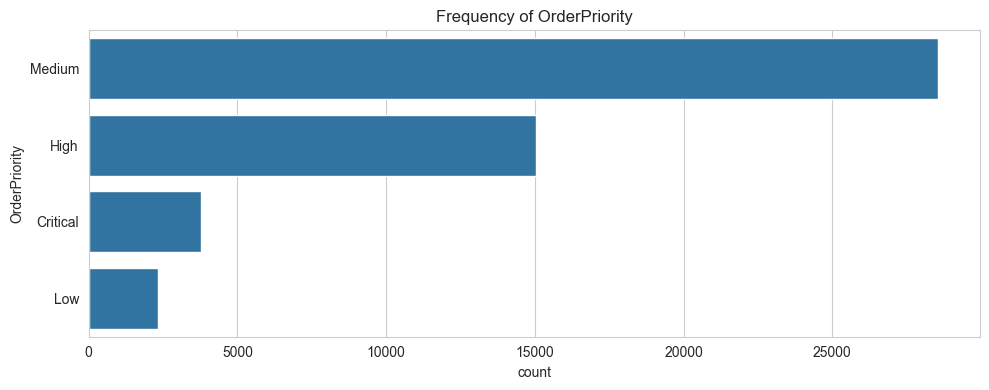

OrderPriority
Medium      57.455204
High        30.275820
Critical     7.588081
Low          4.680894
Name: proportion, dtype: float64


In [10]:
categorical_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Market', 'ShipMode', 'OrderPriority']
eda.plot_categorical_frequencies(categorical_cols)

## Bivariate Analysis: Numerical vs. Numerical

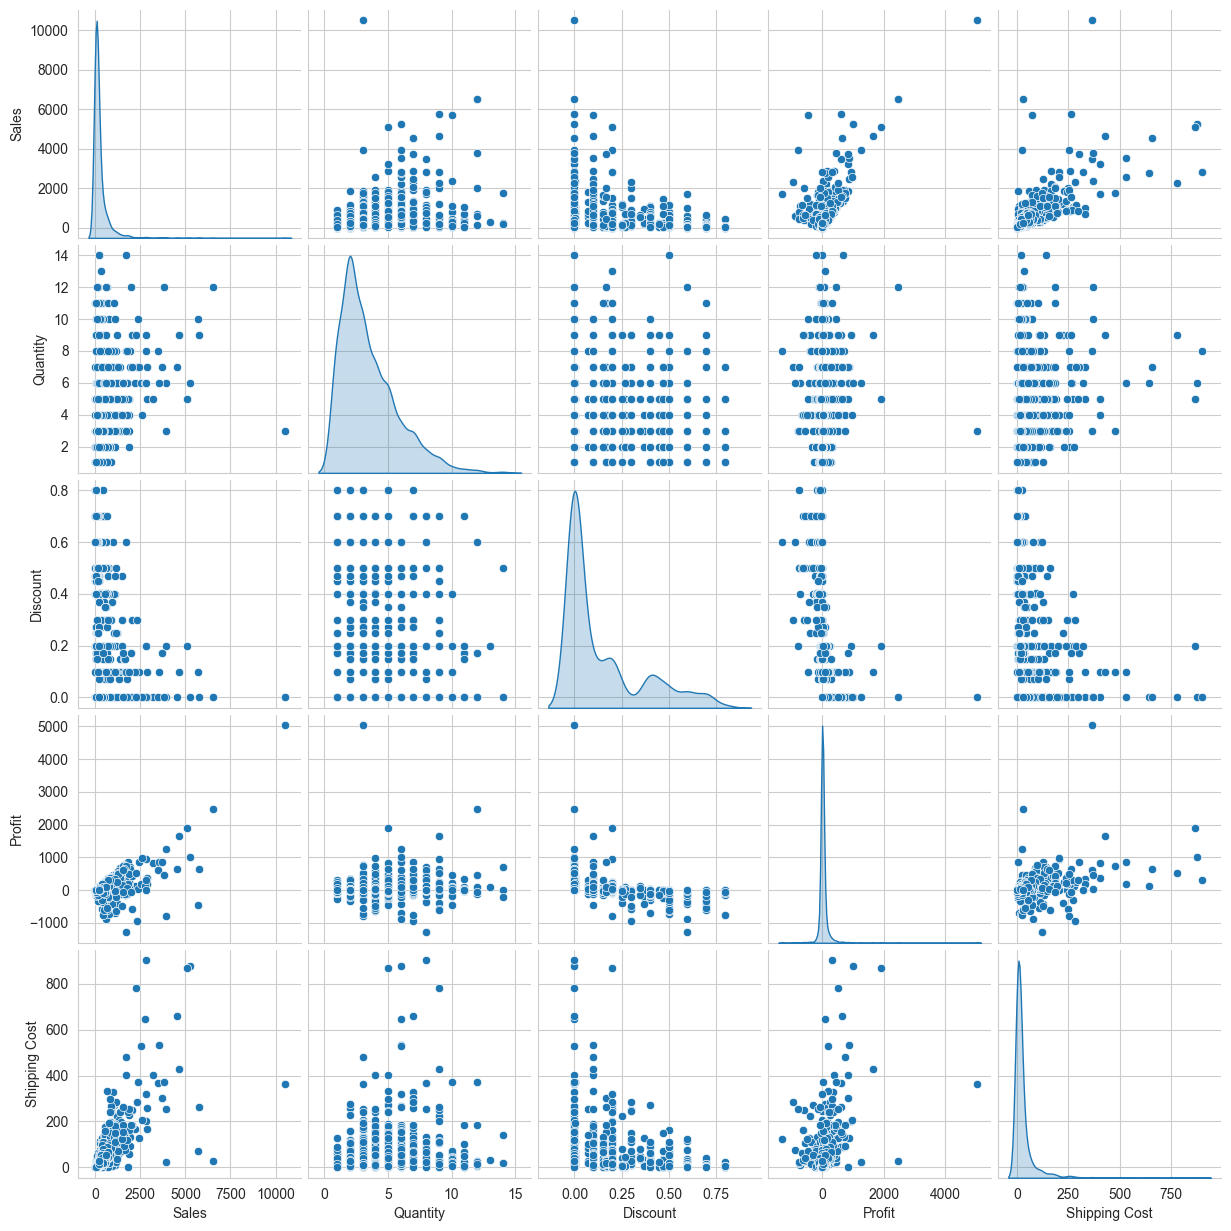

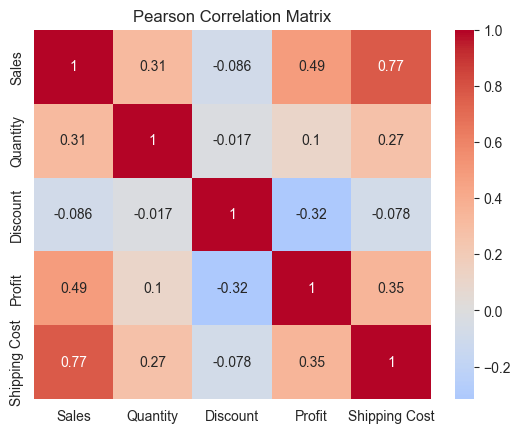

In [11]:
eda.plot_numeric_pairwise(numeric_cols)

## Bivariate Analysis: Numerical vs. Categorical (Comparing means across groups)


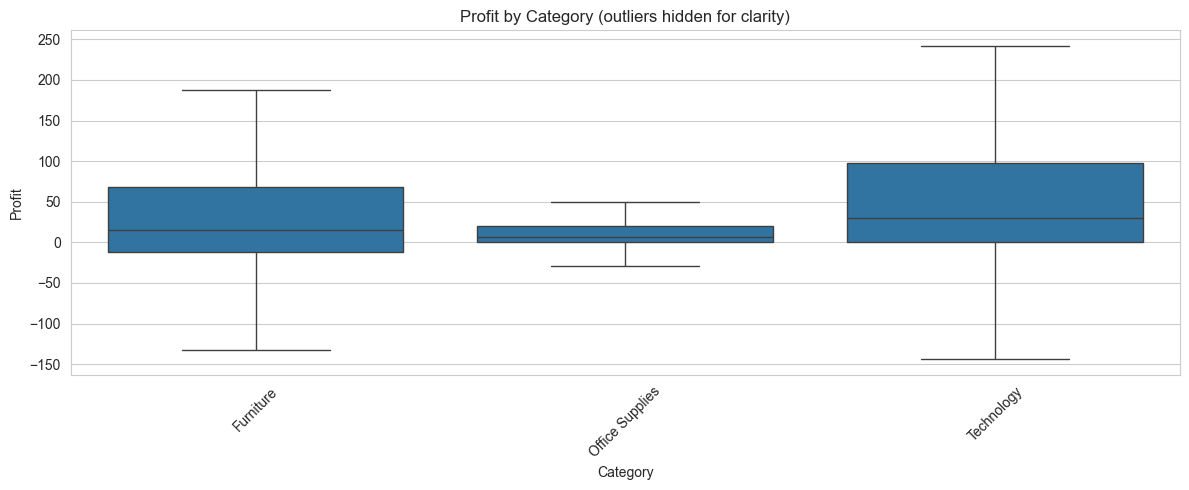

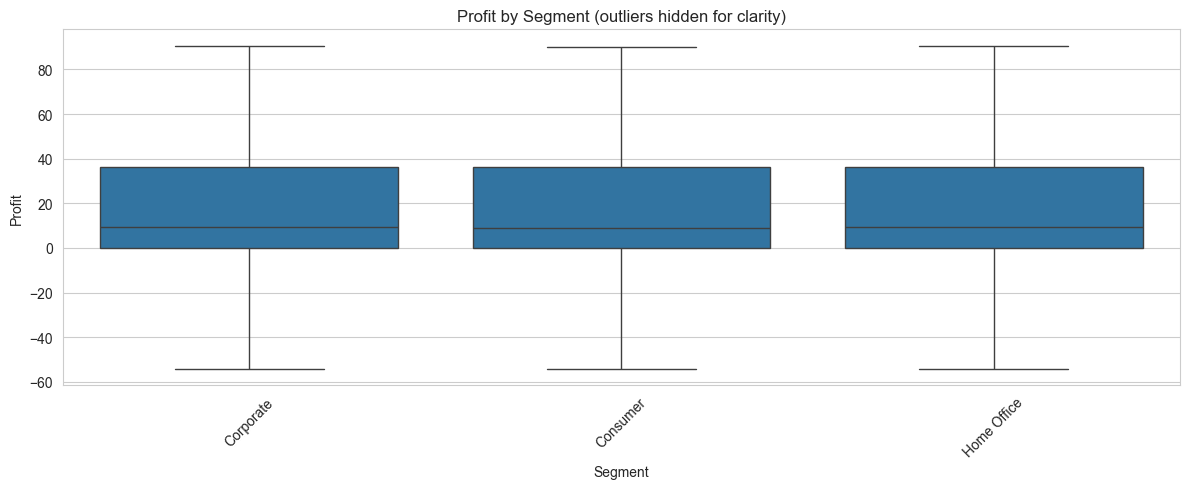

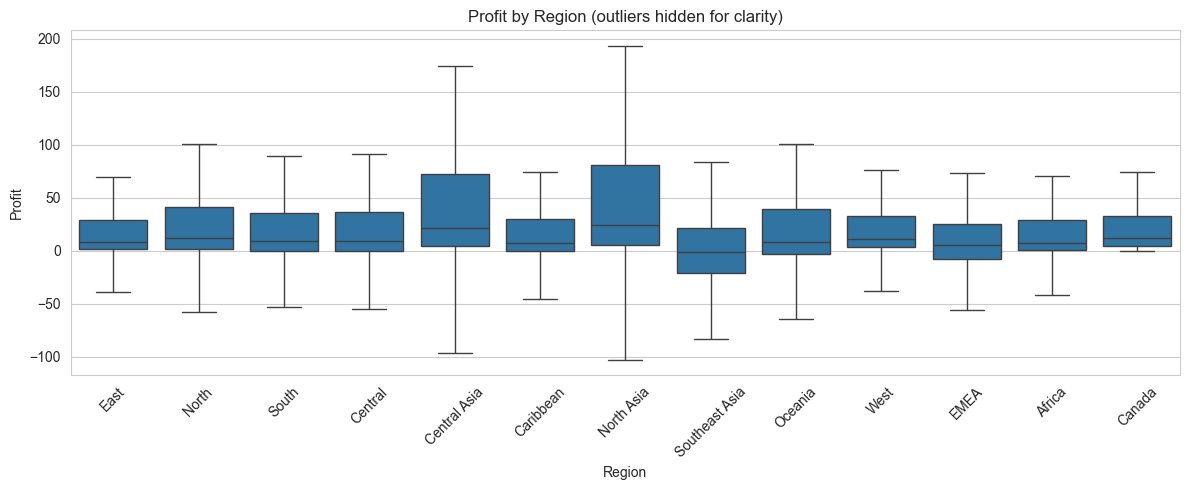

In [12]:
eda.plot_numeric_by_categories(['Category', 'Segment', 'Region'], value_col='Profit')

## Bivariate Analysis: Categorical vs. Categorical

Region           Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  \
Category                                                                        
Furniture           615      40        371     1905           478   730   599   
Office Supplies    2949     273        968     6400          1111  3182  1700   
Technology          889      63        339     1944           459   923   533   

Region           North  North Asia  Oceania  South  Southeast Asia  West  
Category                                                                  
Furniture          906         522      742   1298             687   702  
Office Supplies   2793        1332     1961   3952            1773  1893  
Technology         869         484      784   1240             669   592  


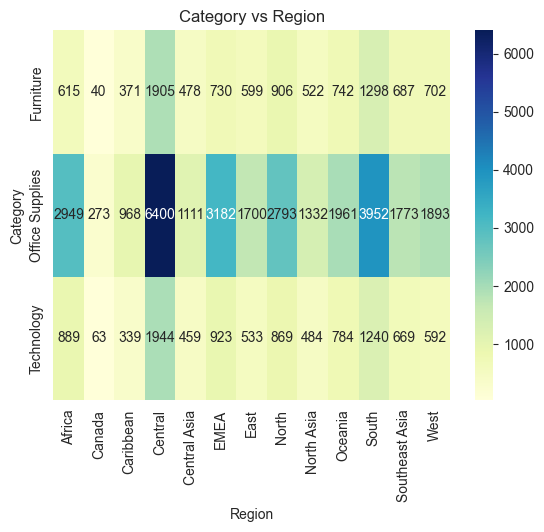

In [13]:
eda.plot_categorical_crosstab_heatmap('Category', 'Region')

## Time Series

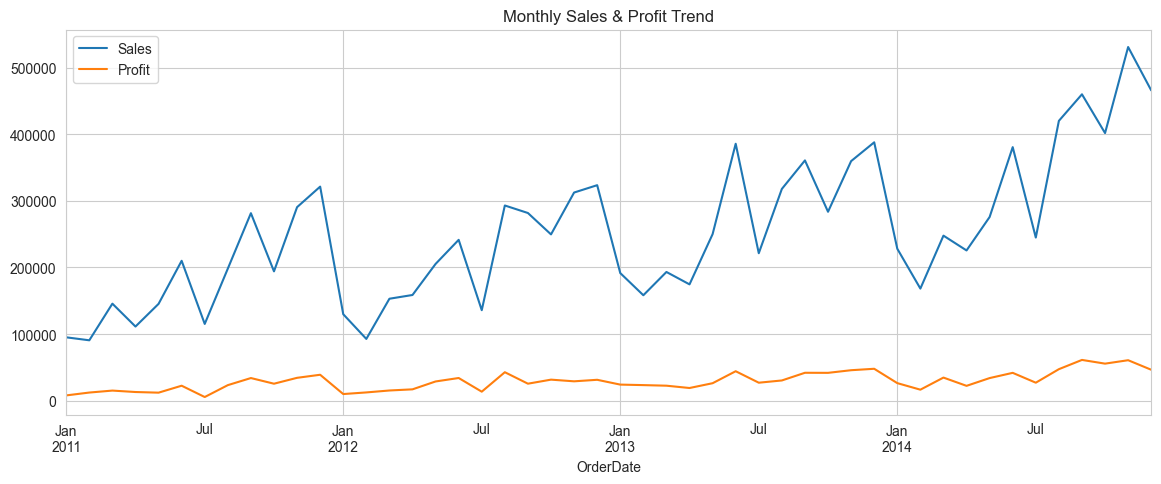

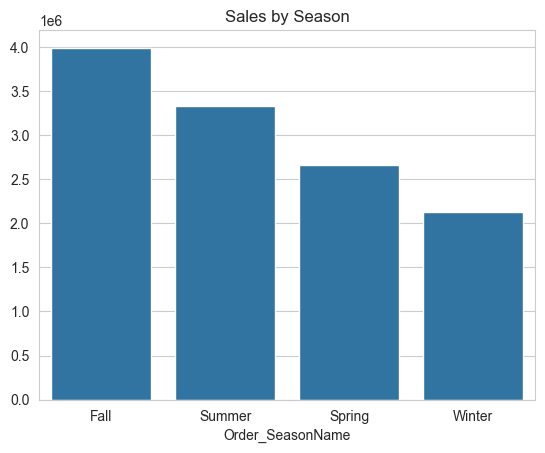

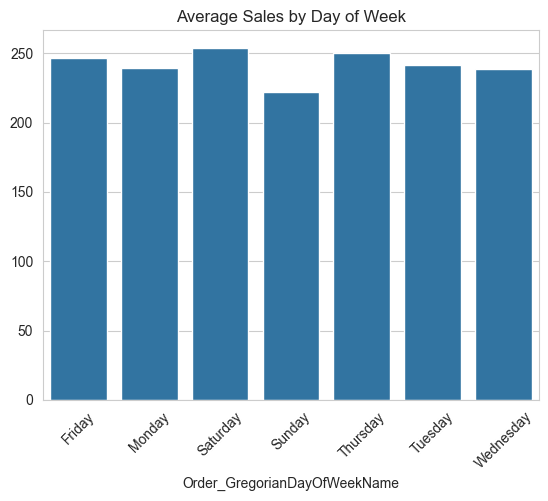

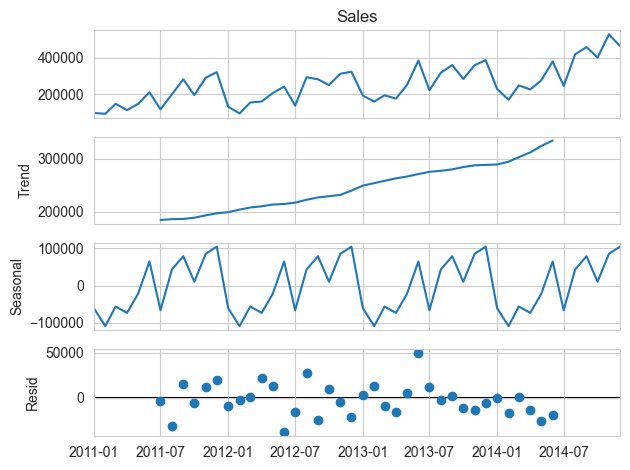

In [14]:
eda.plot_time_series_overview()

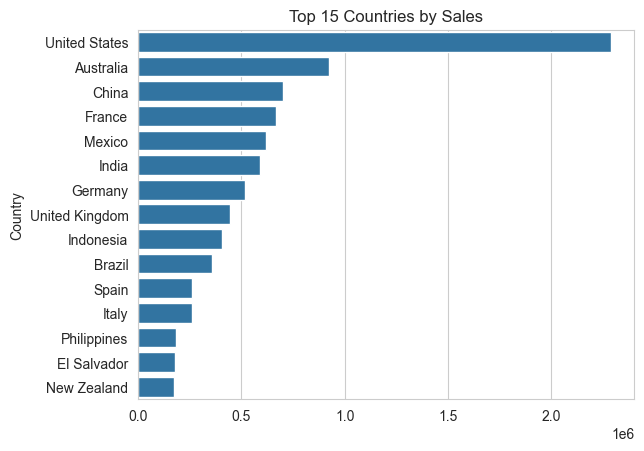

         total_sales  avg_profit  order_count
Market                                       
APAC    3.585744e+06   39.629162         5437
EU      2.482800e+06   34.331468         4593
US      2.287823e+06   28.831310         4990
LATAM   2.150875e+06   21.955399         5120
EMEA    7.754550e+05   10.582015         2462
Africa  7.631486e+05   20.432905         2230
Canada  6.570411e+04   46.947926          201


,total_sales,avg_profit,order_count
Market,,,
APAC,3.585744e+06,39.629162,5437
EU,2.482800e+06,34.331468,4593
US,2.287823e+06,28.831310,4990
LATAM,2.150875e+06,21.955399,5120
EMEA,7.754550e+05,10.582015,2462
Africa,7.631486e+05,20.432905,2230
Canada,6.570411e+04,46.947926,201


In [15]:
eda.plot_top_countries_and_market_summary()

In [16]:
eda.analyze_outliers(numeric_cols)

Sales: 5466 outliers (11.0%)
Quantity: 847 outliers (1.7%)
Discount: 3981 outliers (8.0%)
Profit: 9448 outliers (19.0%)
Shipping Cost: 5744 outliers (11.6%)
              Order ID                                        ProductName  \
38667   CA-2011-145317  Cisco TelePresence System EX90 Videoconferenci...   
9238    CA-2013-118689              Canon imageCLASS 2200 Advanced Copier   
47664   CA-2014-140151              Canon imageCLASS 2200 Advanced Copier   
27082   CA-2014-127180              Canon imageCLASS 2200 Advanced Copier   
6696    CA-2014-166709              Canon imageCLASS 2200 Advanced Copier   
11079   CA-2013-117121   GBC Ibimaster 500 Manual ProClick Binding System   
9175    CA-2011-116904               Ibico EPK-21 Electric Binding System   
10398   US-2013-107440   3D Systems Cube Printer, 2nd Generation, Magenta   
17007   CA-2013-158841  HP Designjet T520 Inkjet Large Format Printer ...   
42753   CA-2013-143714              Canon imageCLASS 2200 Advanced Copier

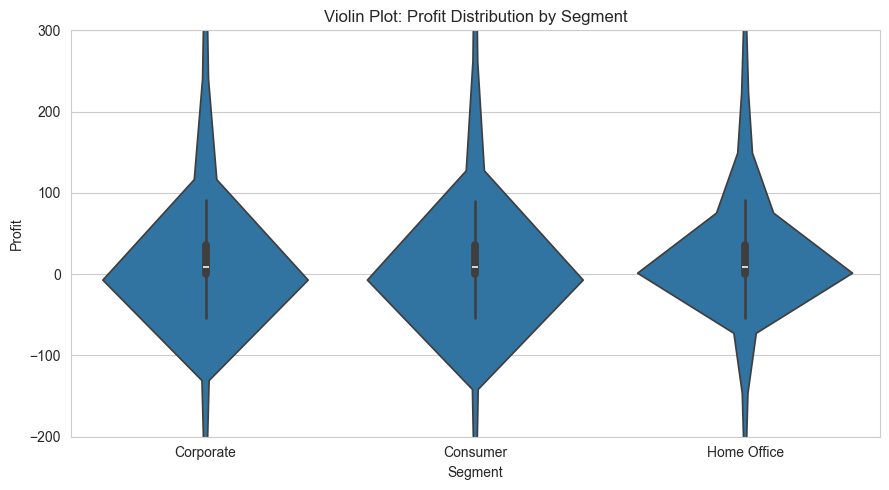

In [17]:
eda.plot_violin_profit_by_segment()

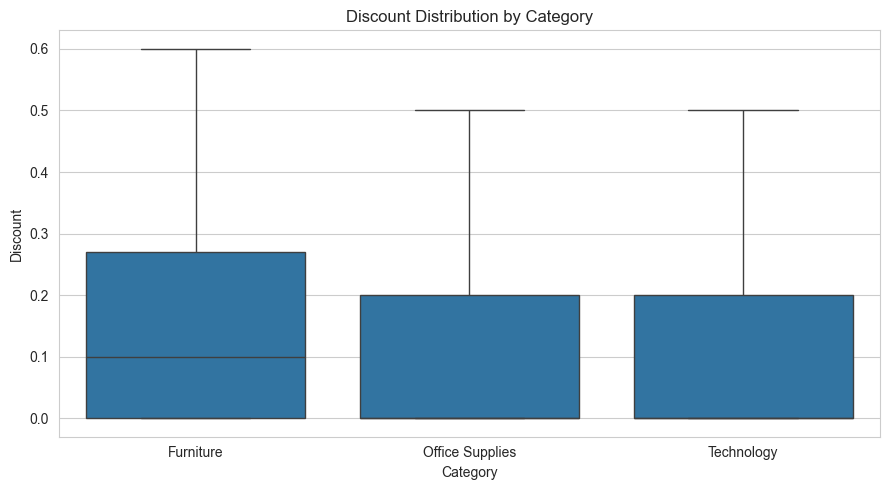

In [18]:
eda.plot_discount_by_category()

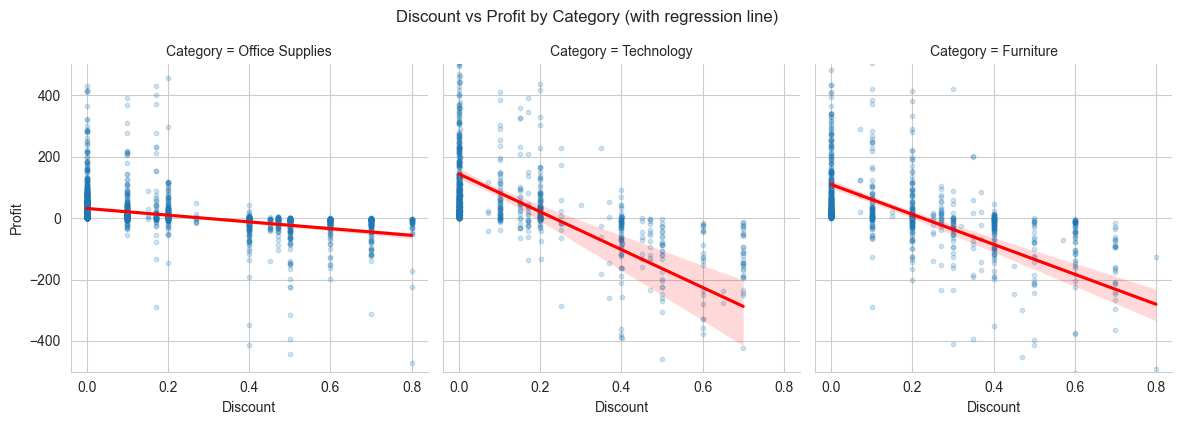

In [19]:
eda.plot_lmplot_discount_profit_by_category()

OrderPriority   Critical  High   Low  Medium
ShipMode                                    
First Class         1671  3287     0    2274
Same Day             708  1247     0     665
Second Class        1390  3881     0    4701
Standard Class         0  6623  2325   20898


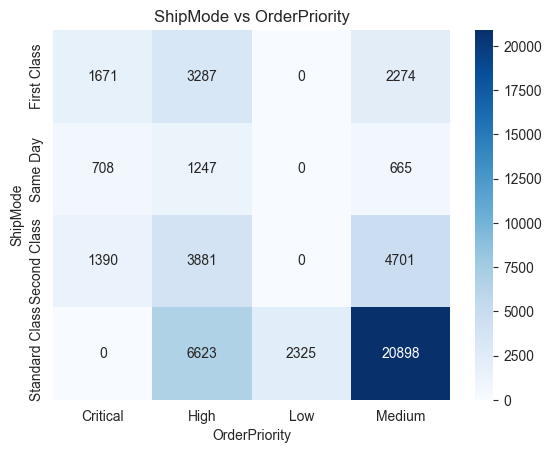

In [20]:
eda.plot_shipmode_priority_heatmap()

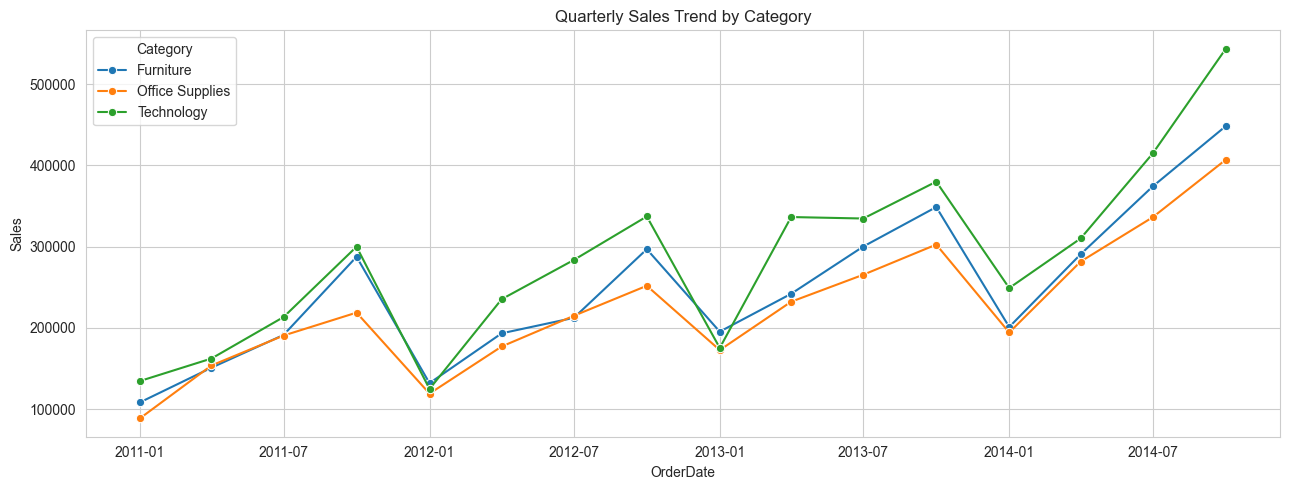

In [21]:
eda.plot_quarterly_trend_by_category()

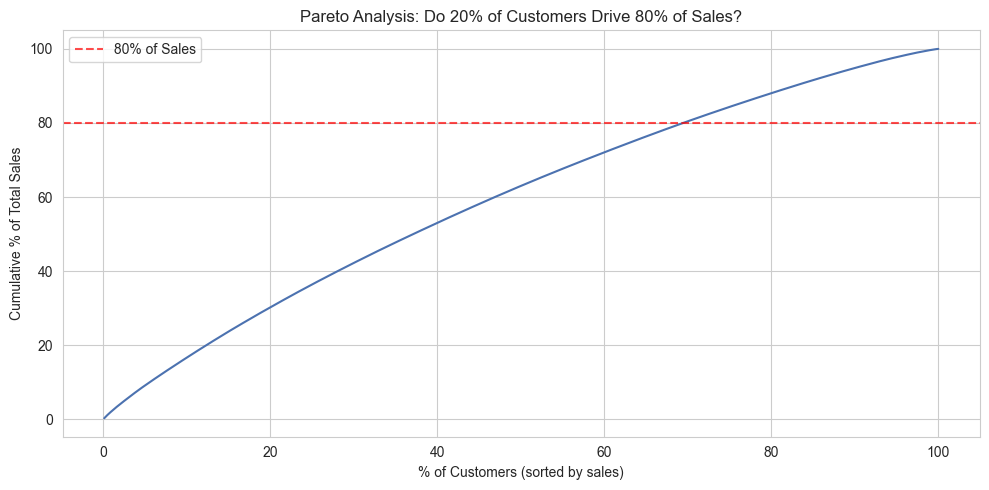

The percentage of customers who account for 80% of sales: 69.3%


np.float64(69.30817610062893)

In [22]:
eda.plot_pareto_customers()

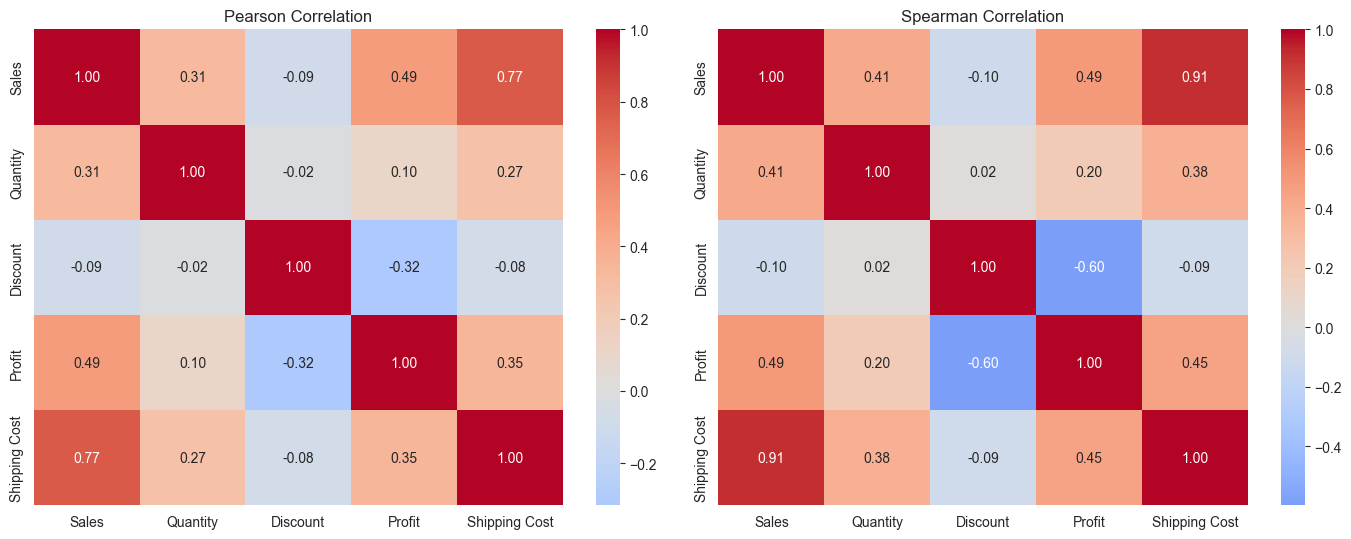

In [23]:
eda.plot_pearson_vs_spearman(numeric_cols)

### Advanced EDA — deeper static views

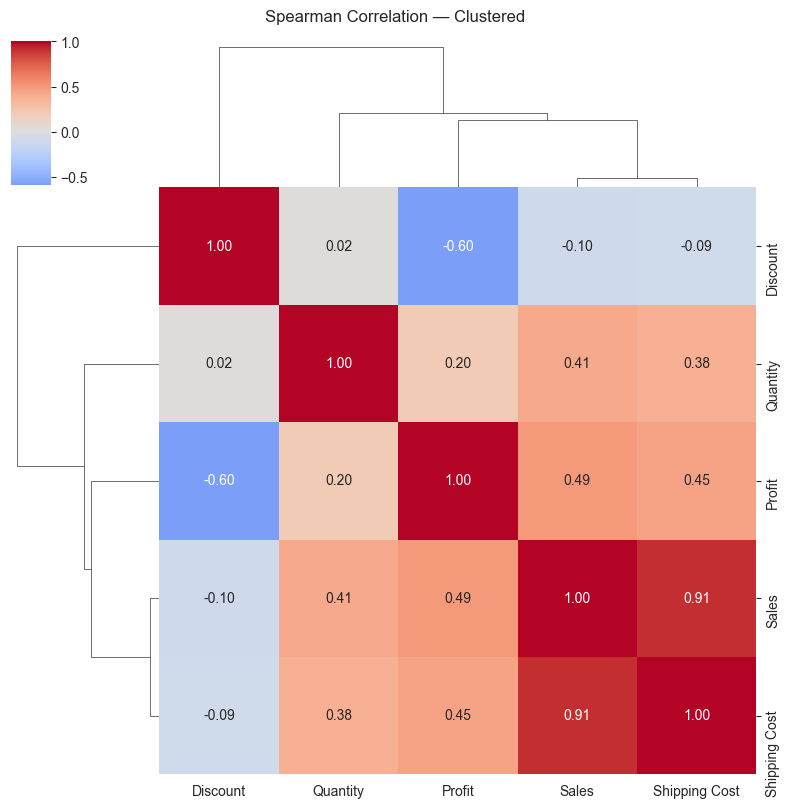

In [24]:
eda.plot_correlation_clustermap(numeric_cols, method='spearman')

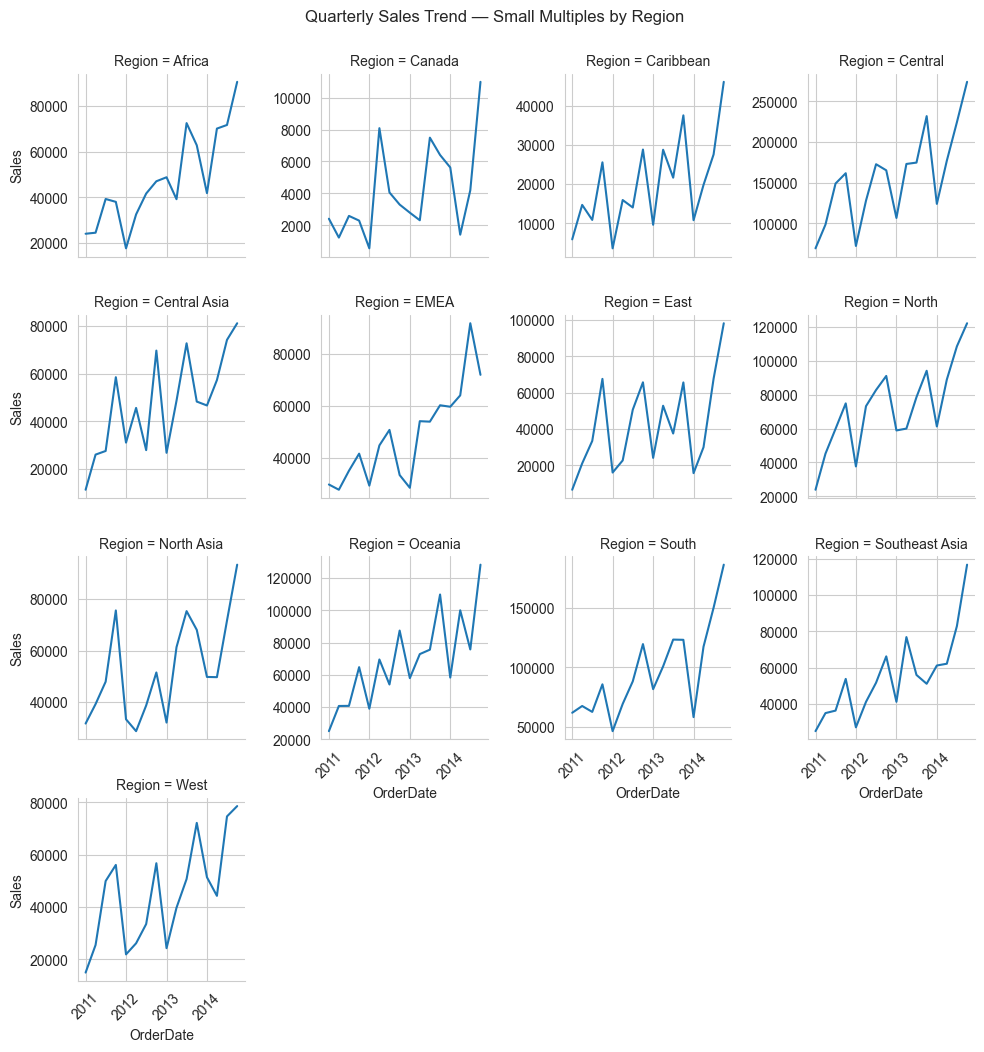

In [25]:
eda.plot_small_multiples_trend_by_region(value_col='Sales')

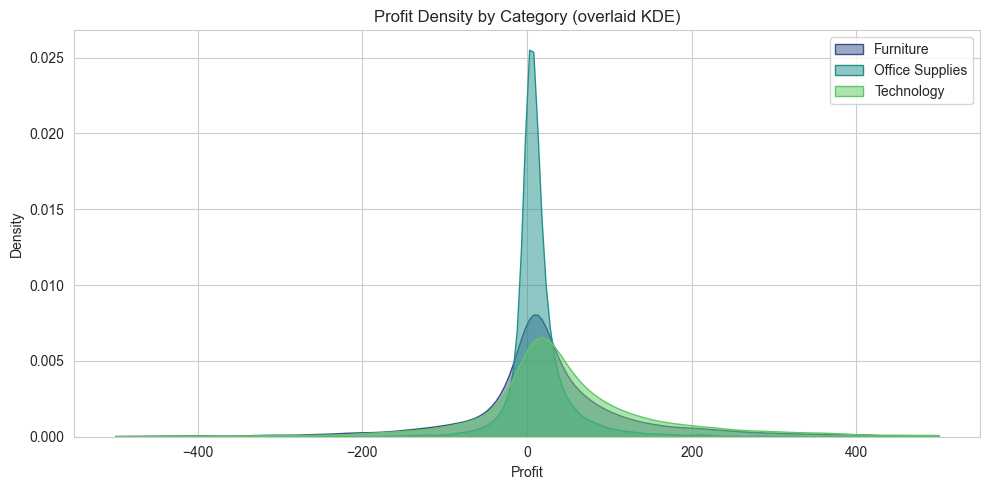

In [26]:
eda.plot_ridge_profit_by_category()

### Interactive EDA (Plotly)

In [27]:
iviz = InteractiveEDA(df)

In [28]:
iviz.scatter_sales_vs_profit()

In [29]:
iviz.treemap_category_subcategory()

In [30]:
iviz.sunburst_geography()

In [31]:
iviz.monthly_trend_with_rangeslider(value_col='Sales')

In [32]:
iviz.choropleth_sales_by_country()

In [33]:
iviz.parallel_categories_returns()

## Statistical Hypothesis Testing

In [34]:
tester = HypothesisTester(df)

### Hypothesis 1: Does Discount Affect the Quantity Sold?

**Research Question:** Does applying a discount to an item lead to a noticeable change in the quantity purchased?

**Groups:** Discounted items (`Discount > 0`) vs. Non-discounted items (`Discount = 0`)

---

**Step 1 — Normality Test (Shapiro-Wilk)**
- H0: The distribution of `Quantity` in the group is normal
- H1: The distribution of `Quantity` in the group is not normal

Result: p ≈ 0.000000 for both groups → **H0 rejected** → data is not normally distributed.

---

**Step 2 — Homogeneity of Variance (Levene's Test)**
- H0: The variances of `Quantity` are equal across the two groups
- H1: The variances of `Quantity` are not equal across the two groups

Result: statistic = 5.85, p = 0.0156 → **H0 rejected** → variances are unequal.

---

**Step 3 — Main Test (Mann-Whitney U, since data is non-normal)**
- H0: The distribution of `Quantity` is the same in both groups (no difference between discounted and non-discounted items)
- H1: The distribution of `Quantity` differs between the two groups

Result: U-statistic, p ≈ 0.000000 → **H0 rejected** → statistically significant difference.

(For reference, Independent t-test with unequal variances: t = 8.41, p ≈ 0.000000 — same conclusion)

---

**Effect Size (Cohen's d)**
Mean difference = 0.173 units, Cohen's d = 0.076 → **negligible effect** (below the 0.2 threshold)

---

**Conclusion:** Although the difference is statistically significant (p < 0.05) due to the large sample size (n=49,670), the practical effect size is negligible (Cohen's d = 0.076). Discounted items are purchased on average only 0.17 units more than non-discounted items — not a meaningful behavioral difference. **The claim that "discounts substantially increase purchase quantity" is not supported.**

has_discount
No discount    28103
Discounted     21567
Name: count, dtype: int64

                count      mean       std  min  25%  50%  75%   max
has_discount                                                       
Discounted    21567.0  3.568507  2.258748  1.0  2.0  3.0  5.0  14.0
No discount   28103.0  3.395794  2.284344  1.0  2.0  3.0  5.0  14.0



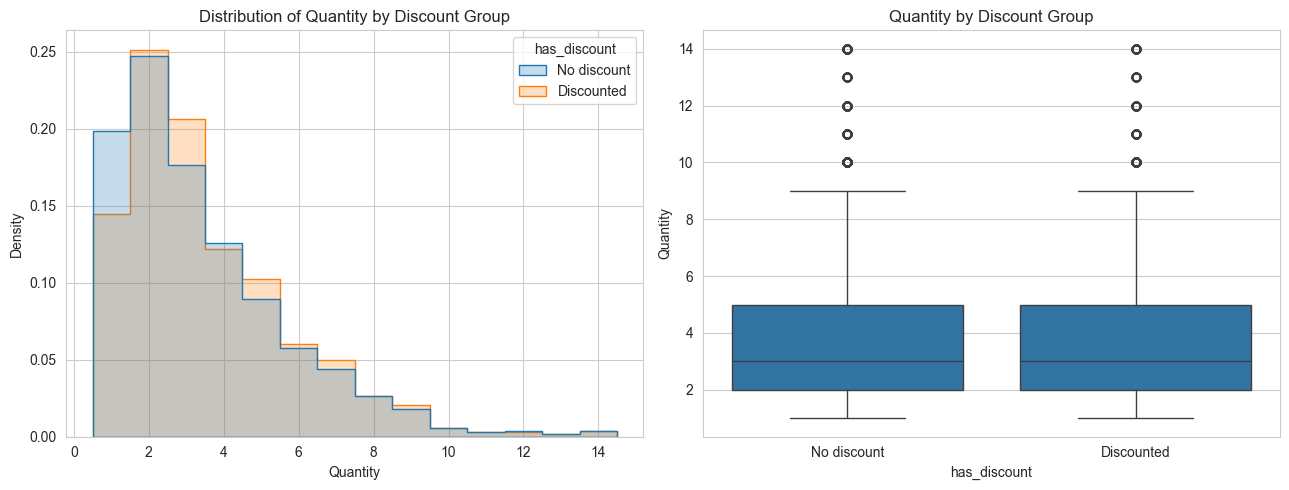

Shapiro-Wilk [Discounted]: p=0.000000 → not normal
Shapiro-Wilk [No discount]: p=0.000000 → not normal

Levene's Test: statistic=5.8522, p=0.015561 → Variances are not equal

Independent t-test: t=8.4051, p=0.000000
Mann-Whitney U: U=320990669.50, p=0.000000  ← Recommended test

Mean Difference: 0.1727
Cohen's d: 0.0760  (negligible)


{'p_ttest': np.float64(4.393281673026962e-17),
 'p_mwu': np.float64(1.236617946793379e-30),
 'cohens_d': np.float64(0.07603220746112231)}

In [35]:
tester.run_hypothesis_discount_vs_quantity()

### Hypothesis 2: Does Profit Differ Across Product Categories?

**Research Question:** Is there a statistically significant difference in average `Profit` among the three product categories (Furniture, Office Supplies, Technology)?

**Groups:** Furniture, Office Supplies, Technology (mean Profit: 28.23, 16.46, 65.46 respectively)

---

**Step 1 — Normality Test (Shapiro-Wilk, per group)**
- H0: `Profit` is normally distributed within each category
- H1: `Profit` is not normally distributed within each category

Result: p ≈ 0.000000 for all three categories → **H0 rejected** → non-normal in all groups.

---

**Step 2 — Homogeneity of Variance (Levene's Test)**
- H0: The variance of `Profit` is equal across all three categories
- H1: At least one category has a different variance

Result: statistic = 1397.54, p ≈ 0.000000 → **H0 rejected** → variances are unequal.

---

**Step 3 — Main Test (Kruskal-Wallis, since data is non-normal with unequal variances)**
- H0: The distribution of `Profit` is the same across all three categories (no difference in central tendency)
- H1: At least one category has a different distribution of `Profit`

Result: H-statistic = 1752.72, p ≈ 0.000000 → **H0 rejected**.

(For reference, One-way ANOVA: F = 302.34, p ≈ 0.000000 — same conclusion)

---

**Step 4 — Post-hoc Pairwise Comparison (Mann-Whitney U with Bonferroni correction, α = 0.0167)**
- H0 (for each pair): The two categories have the same `Profit` distribution
- H1 (for each pair): The two categories have different `Profit` distributions

| Comparison | p-value | Result |
|---|---|---|
| Furniture vs Office Supplies | p ≈ 0.000000 | H0 rejected — significant |
| Furniture vs Technology | p ≈ 0.000000 | H0 rejected — significant |
| Office Supplies vs Technology | p ≈ 0.000000 | H0 rejected — significant |

---

**Conclusion:** All pairwise comparisons are statistically significant, and the magnitude of the differences is substantial (Technology's mean profit is roughly 4x that of Office Supplies). **Technology is a genuinely and meaningfully more profitable category** — this is both statistically and practically significant.

                   count       mean         std          min        25%  \
Category                                                                  
Furniture         9595.0  28.232305  204.021184 -2750.280029 -12.098000   
Office Supplies  30287.0  16.464212  107.285770 -3701.889893   0.450000   
Technology        9788.0  65.458029  269.444431 -6599.979980   0.706725   

                     50%        75%          max  
Category                                          
Furniture        15.3000  68.124599  2316.510010  
Office Supplies   6.4800  20.340000  4946.370117  
Technology       29.5401  97.199997  8399.980469  



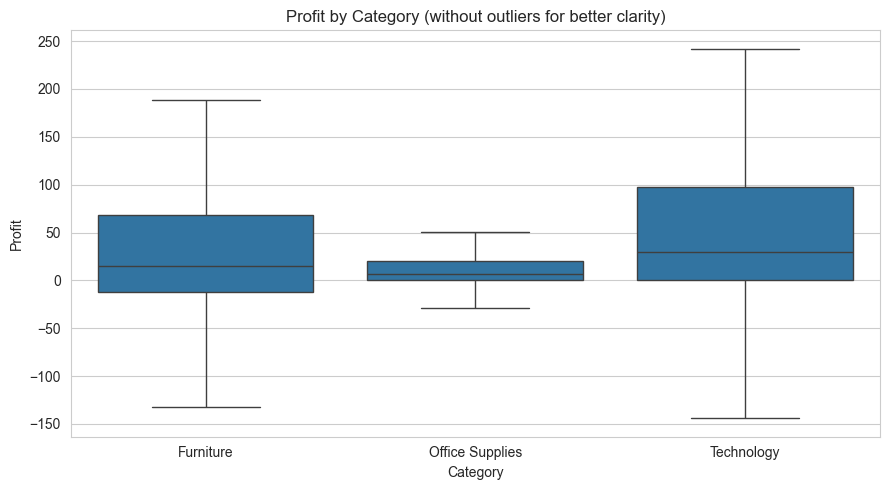

Shapiro [Furniture]: p=0.000000 → Not normal
Shapiro [Office Supplies]: p=0.000000 → Not normal
Shapiro [Technology]: p=0.000000 → Not normal

Levene: statistic=1397.5369, p=0.000000

Kruskal-Wallis: stat=1752.7204, p=0.000000
One-way ANOVA (for comparison): F=302.3449, p=0.000000

Post-hoc pairwise (Mann-Whitney U + Bonferroni correction):
  Furniture vs Office Supplies: p=0.000000 (threshold=0.01667) → Significant | mean1=28.23, mean2=16.46
  Furniture vs Technology: p=0.000000 (threshold=0.01667) → Significant | mean1=28.23, mean2=65.46
  Office Supplies vs Technology: p=0.000000 (threshold=0.01667) → Significant | mean1=16.46, mean2=65.46


{'p_kruskal': np.float64(0.0), 'p_anova': np.float64(3.0631774478815863e-131)}

In [36]:
tester.run_hypothesis_profit_by_category()

### Hypothesis 3: Does Return Rate Differ Across Product Categories?

**Research Question:** Is there an association between product `Category` and whether an item is returned (`IsReturned`)?

**Variables:** Two categorical variables — `Category` (3 levels) and `IsReturned` (Yes/No)

---

**Pre-check — Expected Cell Frequency**
Requirement: all expected cell counts in the contingency table should be ≥ 5 for the Chi-Square test to be valid.

Result: minimum expected count = [value from your run] → assumption satisfied.

---

**Main Test (Chi-Square Test of Independence)**
- H0: `Category` and `IsReturned` are independent (no relationship between them)
- H1: `Category` and `IsReturned` are not independent (there is a relationship)

Result: x^2 = 9.4753, df = 2, p = 0.00876 → **H0 rejected** → statistically significant association.

Return rates by category: Office Supplies 5.75%, Technology 6.24%, Furniture 6.55%

---

**Effect Size (Cramér's V)**
Cramér's V = [value from your run] → **negligible to small association**

---

**Conclusion:** While the Chi-Square test indicates a statistically significant relationship (p < 0.05) — again a consequence of the large sample size — the actual difference in return rates (5.75% to 6.55%, a spread of only 0.8 percentage points) is very small. **The practical significance of this relationship is minimal.**

IsReturned          No   Yes
Category                    
Furniture         8967   628
Office Supplies  28546  1741
Technology        9177   611



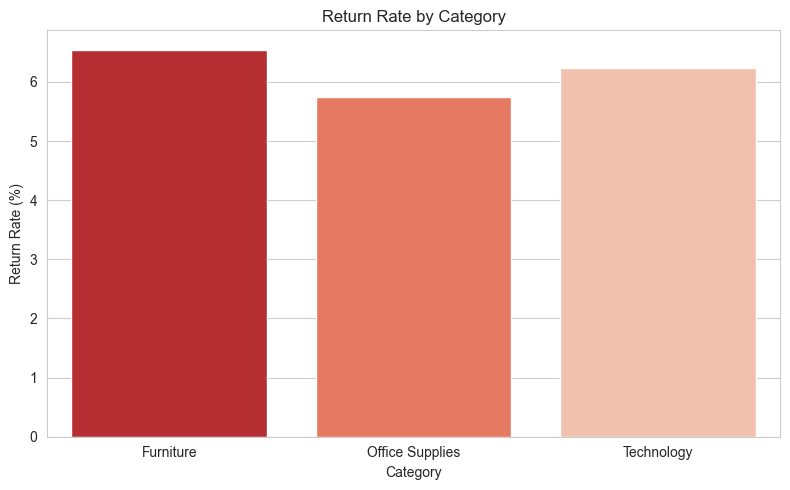

Return Rate by Category (%):
Category
Furniture          6.55
Office Supplies    5.75
Technology         6.24
dtype: float64

Minimum expected count in contingency table: 575.7  (Acceptable (>=5))

Chi-Square: X^2=9.4753, p-value=0.008759, dof=2
Cramér's V: 0.0138  (negligible)


{'chi2': np.float64(9.475254304052706),
 'p': np.float64(0.008759406284906197),
 'cramers_v': np.float64(0.013811738823720311)}

In [37]:
tester.run_hypothesis_return_by_category()

### Hypothesis 4: Is There a Relationship Between Discount and Profit?

**Research Question:** Does increasing the discount level correlate with a decrease in profit? (This directly tests whether stores actually profit more by offering discounts.)

**Variables:** `Discount` (continuous, 0 to 0.85) and `Profit` (continuous, can be negative)

---

**Step 1 — Normality Test (Shapiro-Wilk)**
- H0: The variable is normally distributed
- H1: The variable is not normally distributed

Result: p ≈ 0.000000 for both `Discount` and `Profit` → **H0 rejected** for both → non-normal, favoring Spearman over Pearson.

---

**Step 2 — Correlation Test**

*Pearson (linear relationship, assumes normality):*
- H0: ρ = 0 (no linear correlation between Discount and Profit)
- H1: ρ ≠ 0 (a linear correlation exists)

Result: r = -0.316, p ≈ 0.000000 → **H0 rejected**.

*Spearman (monotonic relationship, robust to non-normality — more appropriate here):*
- H0: There is no monotonic relationship between Discount and Profit
- H1: There is a monotonic relationship between Discount and Profit

Result: ρ (rho) = -0.598, p ≈ 0.000000 → **H0 rejected**.

---

**Conclusion:** Both tests reject the null hypothesis, confirming a **negative and moderately strong relationship** between discount level and profit (Spearman ρ = -0.598 is the more reliable estimate given the skewed distributions). **As discounts increase, profit decreases substantially** — directly contradicting the popular belief that discounting leads to higher profits.

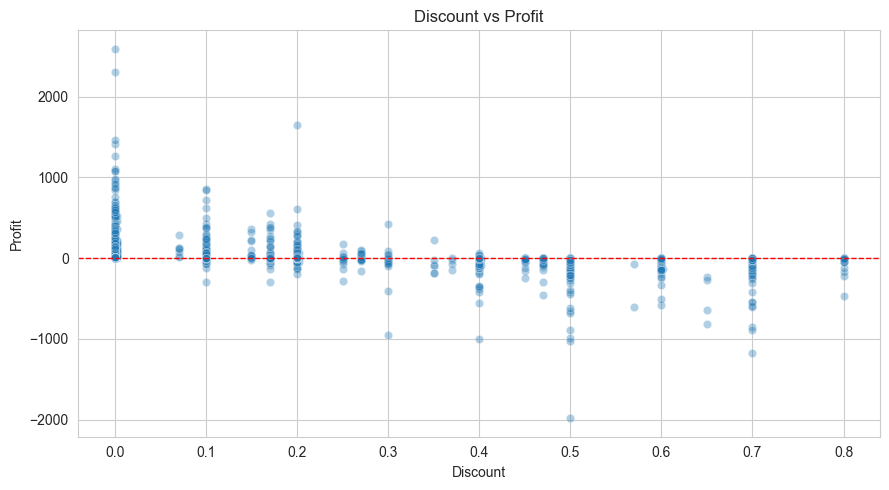

Shapiro [Discount]: p=0.000000 → Not normal
Shapiro [Profit]: p=0.000000 → Not normal

Pearson r=-0.3162, p-value=0.000000
Spearman rho=-0.5982, p-value=0.000000  ← Recommended test (more reliable due to non-normality)


{'pearson_r': np.float64(-0.31620110166620863),
 'spearman_rho': np.float64(-0.5981781834244791)}

In [38]:
tester.run_hypothesis_discount_vs_profit()

### Overall Conclusion

The popular claim — *"stores use discounts to trick people into buying more, ultimately making more money"* — is **not supported by the data**:

1. **Quantity effect:** Discounts have a statistically significant but practically negligible effect on quantity purchased (see Cohen's d above).
2. **Profit effect:** Discounts show a moderately strong **negative** correlation with profit (see Spearman ρ above), directly contradicting the "more profit" claim.

This distinction between **statistical significance** (driven largely by the large sample size) and **practical/effect-size significance** is the central methodological insight of this analysis.